In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

data = pd.read_csv("data.csv")

# Reduce size for speed
data = data.sample(5000, random_state=42)

print(data.head())

            FILENAME                                                URL  \
136221    827598.txt                          https://www.northcm.ac.th   
56609   oph00308.txt  https://unitedmartialartscenters.com/at0/mygov...   
46393    8112660.txt  https://email.mail1.onesignal.os.tc/c/ejwcz02u...   
129746   8135291.txt                                http://uqr.to/1il1z   
131464    586561.txt               https://www.woolworthsrewards.com.au   

        URLLength                        Domain  DomainLength  IsDomainIP  \
136221         24             www.northcm.ac.th            17           0   
56609          59  unitedmartialartscenters.com            28           0   
46393         385   email.mail1.onesignal.os.tc            27           0   
129746         19                        uqr.to             6           0   
131464         35  www.woolworthsrewards.com.au            28           0   

        TLD  URLSimilarityIndex  CharContinuationRate  TLDLegitimateProb  ...  \
13622

In [2]:
print("Shape:", data.shape)
print("Missing:", data.isnull().sum().sum())

Shape: (5000, 56)
Missing: 0


In [3]:
data.fillna(data.mean(numeric_only=True), inplace=True)

for col in data.select_dtypes('object'):
    data[col] = LabelEncoder().fit_transform(data[col])

X = data.drop('label', axis=1)
y = data['label']

print("Preprocessing Done")

Preprocessing Done


In [4]:
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

k_values = range(1, 11)
acc = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred))

print("Training Done")

# Final model (k = 5)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Training Done


Accuracy: 0.996
Confusion Matrix:
 [[534   4]
 [  1 711]]


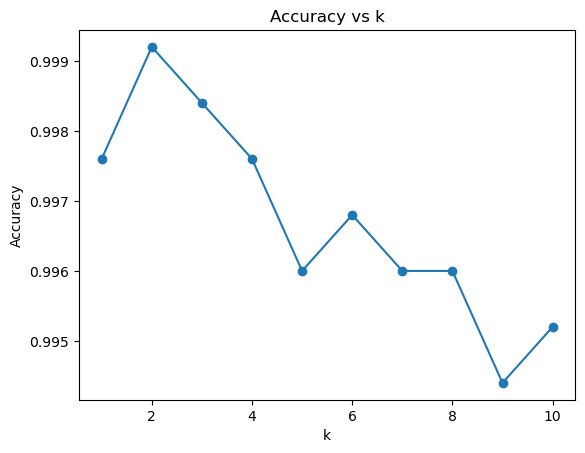

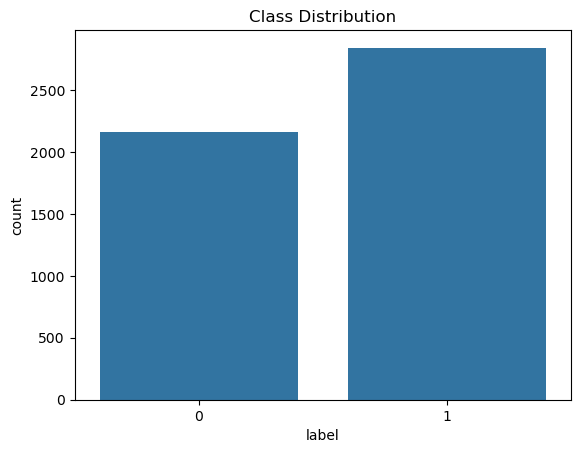

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Graph 1: Accuracy vs k
plt.plot(k_values, acc, marker='o')
plt.title("Accuracy vs k")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.show()

# Graph 2: Class Distribution
sns.countplot(x=y)
plt.title("Class Distribution")
plt.show()